# Alpha Factory Handlers Sandbox

This notebook is a handler-focused copy of the main prototype.
Use this file to migrate processing logic into `alphaFactoryLib` without touching the original notebook.

In [26]:
%load_ext autoreload
%autoreload 2

from collections import deque
import random

import numpy as np
import pandas as pd

from alphaFactoryLib.constants import DATA_WINDOW_LENGTH, DEFAULT_OPERATORS
from alphaFactoryLib.kdb_interface import kdb_link as kdb

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
ops = list(DEFAULT_OPERATORS)

### indicators

In [28]:
from alphaFactoryLib.indicators import (
    FUNCTION_ARR_DICT as functions,
    function_categories,
    reset_indicator_state,
)

# Reset global indicator state before generating a new feature stream.
reset_indicator_state()

In [29]:
from alphaFactoryLib.preprocess_inidcators import preprocess_indicators

params = {
    "script_path": "/home/mica/finProject/finStuff/databases/db_handler_alpha_fac.q",
    "database_path": "/home/mica/finProject/finStuff/databases/db",
    "start_date": "2020.01.01",
    "end_date": "2020.12.31",
    "ticker": "JPM",
    "timeframe": "1d",
}

preprocess_indicators(
    params=params,
    functions=functions,
    output_path="jpm_indicators_preprocessed.csv",
)

reading chunk
Querying kdb for data from 2020-01-01 00:00:00 to 2020-04-10 00:00:00
SMA: None
ADX: None
RSI: None
stochastic_oscillator: None
ATR: None
bollinger_band_width: None
OBV: 0.0
CMF: None
z_score: None
donchian_channel_position: None
SMA: None
ADX: 0
RSI: 0.0
stochastic_oscillator: None
ATR: 5.348751180532708
bollinger_band_width: None
OBV: -10386800.0
CMF: None
z_score: None
donchian_channel_position: None
SMA: None
ADX: 0
RSI: 0.0
stochastic_oscillator: None
ATR: 7.776620826512767
bollinger_band_width: None
OBV: -20645800.0
CMF: None
z_score: None
donchian_channel_position: None
SMA: None
ADX: 0
RSI: 0.0
stochastic_oscillator: None
ATR: 10.850209589126257
bollinger_band_width: None
OBV: -31177100.0
CMF: None
z_score: None
donchian_channel_position: None
SMA: None
ADX: 0
RSI: 19.73920247255495
stochastic_oscillator: None
ATR: 12.760903535914869
bollinger_band_width: None
OBV: -21481800.0
CMF: None
z_score: None
donchian_channel_position: None
SMA: None
ADX: 0
RSI: 26.5760336

In [30]:
from alphaFactoryLib import node

In [31]:
from alphaFactoryLib import build_tree

In [32]:
from alphaFactoryLib import (
    crossover,
    generate_random_tree,
    mutate,
    program_sigmoid_framework,
    simple_framework,
    simple_signal_evaluator,
    tournament_selection,
    tree_size,
)

SIGMOID_SCALING_FACTOR = 25


def sigmoid_framework(program, data):
    return program_sigmoid_framework(program, data, scale=SIGMOID_SCALING_FACTOR)

## Processing Handler Boundary

This notebook currently splits into a few stable stages that should become handlers next:

1. Data acquisition and chunking: KDB / CSV loading into a raw frame.
2. Indicator preprocessing: window management, feature generation, and normalization.
3. Tree execution: program evaluation, signal shaping, and portfolio accounting.
4. Evolution control: population creation, selection, crossover, mutation, and ranking.
5. Diagnostics: OOS backtests, segmented decay checks, and max drawdown summaries.
6. Persistence: experiment logging and sequential result summaries.

The next extraction target is the processing layer that sits between raw data and the evolutionary search loop. That is the clean handoff point for the main processing handlers.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from alphaFactoryLib import evaluate_program as lib_evaluate_program, prepare_dataset_from_csv

COMPLEXITY_LAMBDA = 3e-4

# --- Load and preprocess data via shared library helper ---
prepared_data = prepare_dataset_from_csv(
    "jpm_indicators_preprocessed.csv",
    price_col="price",
    train_fraction=0.7,
    clip_value=5.0,
)

df_raw = prepared_data.raw
train_raw = prepared_data.train_raw
test_raw = prepared_data.test_raw
train = prepared_data.train
test = prepared_data.test
feature_cols = prepared_data.feature_cols
price_col = prepared_data.price_col
mu = prepared_data.mu
sigma = prepared_data.sigma
split_idx = prepared_data.split_idx

print("Train rows:", len(train), "Test rows:", len(test))
print("Feature columns:", len(feature_cols))


def evaluate_program(program, data, signal_fn, cost_bps=5, slippage_bps=2, complexity_lambda=1e-4):
    """Compatibility wrapper so downstream cells keep working unchanged."""
    return lib_evaluate_program(
        program,
        data,
        signal_fn,
        price_col=price_col,
        cost_bps=cost_bps,
        slippage_bps=slippage_bps,
        complexity_lambda=complexity_lambda,
    )

Train rows: 193 Test rows: 84
Feature columns: 10


In [34]:
FITNESS_CUTOFF = 0.3
INITIAL_POPULATION = 250
GENERATIONS = 25
MIN_DEPTH = 1
MAX_DEPTH = 4


programs = []
for i in range(INITIAL_POPULATION):
    depth = random.randint(MIN_DEPTH, MAX_DEPTH)
    method = "full" if i % 2 == 0 else "grow"
    programs.append(build_tree(current_depth=0, max_depth=depth, method=method))

print("Sample programs:")
for i in range(5):
    print(f"Program {i}: {programs[i]}")

Sample programs:
Program 0: ((((CMF + stochastic_oscillator) / (ADX - OBV)) * ((bollinger_band_width - ADX) + (donchian_channel_position + CMF))) + (((ATR - SMA) + (z_score - OBV)) - ((RSI + donchian_channel_position) - (ATR * RSI))))
Program 1: (CMF * (CMF - donchian_channel_position))
Program 2: ((((ATR / SMA) - (CMF * bollinger_band_width)) - ((donchian_channel_position + stochastic_oscillator) * (ATR - bollinger_band_width))) + (((ADX / CMF) + (z_score - stochastic_oscillator)) + ((ATR / ATR) * (ATR - RSI))))
Program 3: (SMA - z_score)
Program 4: (donchian_channel_position * RSI)


In [35]:
MUTATION_RATE = 0.45
TOURNAMENT_SIZE = 2

# Baseline evolution now includes anti-overfit and anti-bloat pressure.
EVO_VAL_FRACTION = 0.20
EVO_TRAIN_WEIGHT = 0.60
EVO_VAL_WEIGHT = 0.40
EVO_GAP_PENALTY = 0.75
EVO_BLOAT_PENALTY = 0.0025
EVO_MAX_TREE_NODES = 55
EVO_COMPLEXITY_LAMBDA = 8e-4

gen_history = []
IMMIGRANT_FRAC = 0.10

split_inner_idx = int(len(train) * (1.0 - EVO_VAL_FRACTION))
train_inner = train.iloc[:split_inner_idx].copy()
train_val = train.iloc[split_inner_idx:].copy()

print(f"Evolution inner-train rows: {len(train_inner)} | val rows: {len(train_val)}")

for generation in range(GENERATIONS):
    # --- Evaluate population on train_inner + validation ---
    fitnesses = []
    move_counts = []
    expr_set = set()

    for program in programs:
        train_stats = evaluate_program(
            program,
            train_inner,
            signal_fn=sigmoid_framework,
            cost_bps=5,
            slippage_bps=2,
            complexity_lambda=EVO_COMPLEXITY_LAMBDA,
        )
        val_stats = evaluate_program(
            program,
            train_val,
            signal_fn=sigmoid_framework,
            cost_bps=5,
            slippage_bps=2,
            complexity_lambda=EVO_COMPLEXITY_LAMBDA,
        )

        t_nodes = tree_size(program)
        overfit_gap = max(0.0, train_stats["fitness"] - val_stats["fitness"])

        evo_score = (
            EVO_TRAIN_WEIGHT * train_stats["fitness"]
            + EVO_VAL_WEIGHT * val_stats["fitness"]
            - EVO_GAP_PENALTY * overfit_gap
            - EVO_BLOAT_PENALTY * t_nodes
        )

        program.set_fitness(float(evo_score))
        program.moves = train_stats["moves"]
        program.train_inner_fitness = train_stats["fitness"]
        program.val_fitness = val_stats["fitness"]
        program.node_count = t_nodes

        fitnesses.append(program.fitness)
        move_counts.append(program.moves)
        expr_set.add(str(program))

    fitnesses_arr = np.array(fitnesses, dtype=float)

    # Save generation metrics
    gen_history.append(
        {
            "generation": generation,
            "best_fitness": float(np.max(fitnesses_arr)),
            "median_fitness": float(np.median(fitnesses_arr)),
            "std_fitness": float(np.std(fitnesses_arr)),
            "mean_moves": float(np.mean(move_counts)),
            "unique_expr_ratio": float(len(expr_set) / len(programs)),
            "mean_nodes": float(np.mean([tree_size(p) for p in programs])),
            "best_val_fitness": float(max(getattr(p, "val_fitness", -1e9) for p in programs)),
        }
    )

    n_imm = int(len(programs) * IMMIGRANT_FRAC)

    # Keep best programs, replace worst with fresh random trees
    programs_sorted = sorted(programs, key=lambda p: p.fitness, reverse=True)
    survivors = programs_sorted[:-n_imm]

    immigrants = []
    for _ in range(n_imm):
        d = random.randint(MIN_DEPTH, MAX_DEPTH)
        m = "full" if random.random() < 0.5 else "grow"
        immigrants.append(build_tree(current_depth=0, max_depth=d, method=m))

    programs = survivors + immigrants

    # --- Create next generation ---
    next_generation = []
    best_program = max(programs, key=lambda p: p.fitness)
    next_generation.append(best_program.copy())  # elitism

    while len(next_generation) < len(programs):
        p1 = tournament_selection(programs, tournament_size=TOURNAMENT_SIZE)
        p2 = tournament_selection(programs, tournament_size=TOURNAMENT_SIZE)

        c1, c2 = crossover(p1, p2)

        if random.random() < MUTATION_RATE:
            c1 = mutate(c1, functions, ops)
        if random.random() < MUTATION_RATE:
            c2 = mutate(c2, functions, ops)

        # Hard bloat guard: replace oversized trees with fresh bounded trees.
        if tree_size(c1) > EVO_MAX_TREE_NODES:
            d = random.randint(MIN_DEPTH, MAX_DEPTH)
            m = "full" if random.random() < 0.5 else "grow"
            c1 = build_tree(current_depth=0, max_depth=d, method=m)
        if tree_size(c2) > EVO_MAX_TREE_NODES:
            d = random.randint(MIN_DEPTH, MAX_DEPTH)
            m = "full" if random.random() < 0.5 else "grow"
            c2 = build_tree(current_depth=0, max_depth=d, method=m)

        next_generation.append(c1)
        if len(next_generation) < len(programs):
            next_generation.append(c2)

    programs = next_generation

    # Quick progress print
    g = gen_history[-1]
    print(
        f"Gen {generation:02d} | "
        f"score={g['best_fitness']:.6f} "
        f"best_val={g['best_val_fitness']:.6f} "
        f"median={g['median_fitness']:.6f} "
        f"nodes={g['mean_nodes']:.1f} "
        f"moves={g['mean_moves']:.1f} "
        f"div={g['unique_expr_ratio']:.2f}"
    )

history_df = pd.DataFrame(gen_history)
display(history_df.tail())

print("Best evolution score seen:", history_df["best_fitness"].max())
print("Best val fitness seen:", history_df["best_val_fitness"].max())
print("Mean nodes last gen:", history_df["mean_nodes"].iloc[-1])
print("Diversity last gen:", history_df["unique_expr_ratio"].iloc[-1])

Evolution inner-train rows: 154 | val rows: 39
Gen 00 | score=-0.197455 best_val=0.017646 median=-0.516050 nodes=9.9 moves=24.8 div=0.96
Gen 01 | score=-0.305213 best_val=0.189048 median=-0.503691 nodes=7.6 moves=16.1 div=0.88
Gen 02 | score=-0.266221 best_val=0.154780 median=-0.505400 nodes=7.0 moves=17.5 div=0.85
Gen 03 | score=-0.156994 best_val=0.086348 median=-0.500061 nodes=6.7 moves=16.5 div=0.80
Gen 04 | score=-0.156994 best_val=0.115809 median=-0.502368 nodes=6.5 moves=18.0 div=0.77
Gen 05 | score=-0.156994 best_val=0.074794 median=-0.501920 nodes=6.1 moves=14.8 div=0.77
Gen 06 | score=-0.072653 best_val=0.270016 median=-0.498502 nodes=6.4 moves=14.3 div=0.70
Gen 07 | score=-0.072653 best_val=0.830249 median=-0.497091 nodes=6.3 moves=15.1 div=0.66
Gen 08 | score=0.022913 best_val=0.384412 median=-0.497091 nodes=6.7 moves=18.7 div=0.70
Gen 09 | score=0.022913 best_val=0.513293 median=-0.497091 nodes=6.7 moves=20.5 div=0.71
Gen 10 | score=0.125981 best_val=0.384412 median=-0.497

,generation,best_fitness,median_fitness,std_fitness,mean_moves,unique_expr_ratio,mean_nodes,best_val_fitness
20,20,0.144673,-0.497091,0.167913,26.404,0.796,10.032,1.031179
21,21,0.145605,-0.497091,0.204152,24.968,0.812,10.304,1.137627
22,22,0.433531,-0.503691,0.282743,28.172,0.844,11.432,1.596792
23,23,0.510430,-0.508079,0.273103,34.416,0.868,12.480,1.620860
24,24,0.510430,-0.510291,0.228911,29.564,0.880,11.528,1.620860


Best evolution score seen: 0.5104299992872924
Best val fitness seen: 1.6208597987415616
Mean nodes last gen: 11.528
Diversity last gen: 0.88


In [36]:
# Best on TRAIN
best_program = max(programs, key=lambda p: p.fitness)

train_stats = evaluate_program(
    best_program, train, signal_fn=sigmoid_framework,
    cost_bps=5, slippage_bps=2, complexity_lambda=COMPLEXITY_LAMBDA
)
test_stats = evaluate_program(
    best_program, test, signal_fn=sigmoid_framework,
    cost_bps=5, slippage_bps=2, complexity_lambda=COMPLEXITY_LAMBDA
)

print("Best program expression:")
print(best_program)
print("\nTRAIN stats:", train_stats)
print("TEST stats :", test_stats)

overfit_gap = train_stats["fitness"] - test_stats["fitness"]
print(f"\nOverfit gap (train - test fitness): {overfit_gap:.6f}")

Best program expression:
(((bollinger_band_width * (ADX / RSI)) - ((stochastic_oscillator - ADX) / (SMA * SMA))) * (((CMF - RSI) / (ADX - z_score)) / ((stochastic_oscillator - stochastic_oscillator) + (OBV * stochastic_oscillator))))

TRAIN stats: {'fitness': 0.0871632271244468, 'raw_fitness': 0.2046715172798872, 'penalty': 0.0087, 'moves': 140, 'final_value': 1114.959840896799, 'num_steps': 193}
TEST stats : {'fitness': 0.681761391201618, 'raw_fitness': 0.783318534058761, 'penalty': 0.0087, 'moves': 52, 'final_value': 1079.5900044617865, 'num_steps': 84}

Overfit gap (train - test fitness): -0.594598


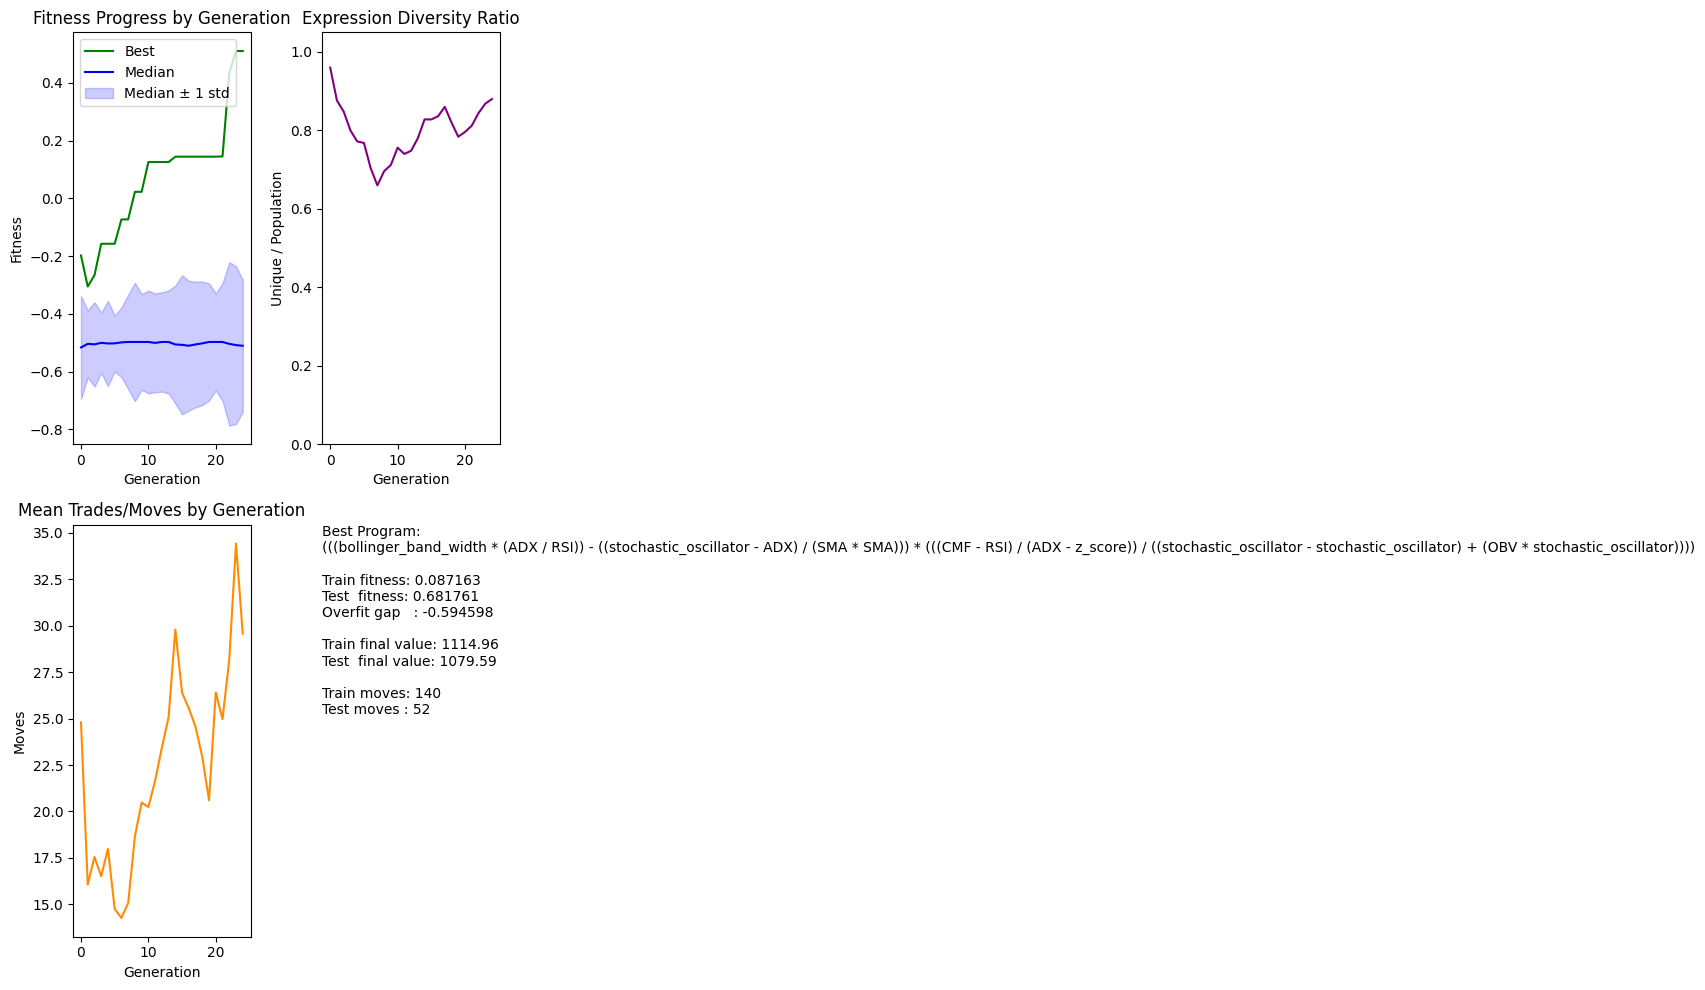

In [37]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Fitness trajectory
axs[0, 0].plot(history_df["generation"], history_df["best_fitness"], label="Best", color="green")
axs[0, 0].plot(history_df["generation"], history_df["median_fitness"], label="Median", color="blue")
axs[0, 0].fill_between(
    history_df["generation"],
    history_df["median_fitness"] - history_df["std_fitness"],
    history_df["median_fitness"] + history_df["std_fitness"],
    alpha=0.2, color="blue", label="Median ± 1 std"
)
axs[0, 0].set_title("Fitness Progress by Generation")
axs[0, 0].set_xlabel("Generation")
axs[0, 0].set_ylabel("Fitness")
axs[0, 0].legend()

# Diversity
axs[0, 1].plot(history_df["generation"], history_df["unique_expr_ratio"], color="purple")
axs[0, 1].set_title("Expression Diversity Ratio")
axs[0, 1].set_xlabel("Generation")
axs[0, 1].set_ylabel("Unique / Population")
axs[0, 1].set_ylim(0, 1.05)

# Moves profile
axs[1, 0].plot(history_df["generation"], history_df["mean_moves"], color="darkorange")
axs[1, 0].set_title("Mean Trades/Moves by Generation")
axs[1, 0].set_xlabel("Generation")
axs[1, 0].set_ylabel("Moves")

# Train/Test summary
axs[1, 1].axis("off")
axs[1, 1].text(
    0.0, 1.0,
    "\n".join([
        f"Best Program:",
        f"{best_program}",
        "",
        f"Train fitness: {train_stats['fitness']:.6f}",
        f"Test  fitness: {test_stats['fitness']:.6f}",
        f"Overfit gap   : {train_stats['fitness'] - test_stats['fitness']:.6f}",
        "",
        f"Train final value: {train_stats['final_value']:.2f}",
        f"Test  final value: {test_stats['final_value']:.2f}",
        "",
        f"Train moves: {train_stats['moves']}",
        f"Test moves : {test_stats['moves']}",
    ]),
    va="top",
    fontsize=10
)

plt.tight_layout()
plt.show()

In [38]:
# Quick OOS backtest: evaluate top train performers on 2021 data
TOP_K = 10
OOS_PATH = "jpm_indicators_preprocessed_out_of_sample_2021.csv"

# 1) Re-evaluate current population on TRAIN so rankings are consistent
for p in programs:
    s = evaluate_program(
        p,
        train,
        signal_fn=sigmoid_framework,
        cost_bps=5,
        slippage_bps=2,
        complexity_lambda=COMPLEXITY_LAMBDA,
    )
    p.set_fitness(s["fitness"])

ranked = sorted(programs, key=lambda p: p.fitness, reverse=True)
top_programs = ranked[:TOP_K]

# 2) Load 2021 OOS data and preprocess with TRAIN mu/sigma (no leakage)
oos_raw = pd.read_csv(OOS_PATH)
if "Unnamed: 0" in oos_raw.columns:
    oos_raw = oos_raw.drop(columns=["Unnamed: 0"])

for c in oos_raw.columns:
    oos_raw[c] = pd.to_numeric(oos_raw[c], errors="coerce")

if price_col not in oos_raw.columns:
    raise ValueError(f"Expected '{price_col}' column in {OOS_PATH}")

missing_feats = [c for c in feature_cols if c not in oos_raw.columns]
if missing_feats:
    raise ValueError(f"Missing feature columns in OOS file: {missing_feats[:8]}")

oos = oos_raw.copy()
oos[feature_cols] = (oos_raw[feature_cols] - mu) / sigma
oos[feature_cols] = oos[feature_cols].clip(-5, 5)
oos = oos.fillna(0.0)

# 3) Backtest top programs on OOS 2021
rows = []
for rank, p in enumerate(top_programs, start=1):
    train_s = evaluate_program(
        p,
        train,
        signal_fn=sigmoid_framework,
        cost_bps=5,
        slippage_bps=2,
        complexity_lambda=COMPLEXITY_LAMBDA,
    )
    oos_s = evaluate_program(
        p,
        oos,
        signal_fn=sigmoid_framework,
        cost_bps=5,
        slippage_bps=2,
        complexity_lambda=COMPLEXITY_LAMBDA,
    )

    rows.append({
        "rank": rank,
        "train_fitness": train_s["fitness"],
        "oos_fitness_2021": oos_s["fitness"],
        "oos_raw_2021": oos_s["raw_fitness"],
        "oos_final_value_2021": oos_s["final_value"],
        "oos_moves_2021": oos_s["moves"],
        "program": str(p),
    })

results_2021 = pd.DataFrame(rows).sort_values("oos_fitness_2021", ascending=False)
display(results_2021)

print("Top 3 by OOS 2021 fitness:")
for _, r in results_2021.head(3).iterrows():
    print(
        f"#{int(r['rank'])} | oos_fit={r['oos_fitness_2021']:.6f} | "
        f"final={r['oos_final_value_2021']:.2f} | moves={int(r['oos_moves_2021'])}"
    )

,rank,train_fitness,oos_fitness_2021,oos_raw_2021,oos_final_value_2021,oos_moves_2021,program
0,1,0.355352,0.578357,0.675435,2130.100794,970,(((((ADX * z_score) + CMF) - SMA) / (donchian_...
4,5,0.004864,0.487640,0.617284,2034.671329,1319,(((((ADX * z_score) + CMF) - SMA) / (donchian_...
1,2,0.273013,0.433941,0.533628,1894.577248,979,(((((ADX * z_score) + CMF) - SMA) / (donchian_...
8,9,-0.201093,0.142611,0.153079,1246.070669,13,((((RSI + CMF) * (z_score / OBV)) * ((OBV / AD...
6,7,-0.093328,0.142587,0.170032,1273.459193,282,((ADX - CMF) - (RSI / CMF))
3,4,0.067454,0.042691,0.111933,1307.653955,707,((z_score + (((((bollinger_band_width - ATR) -...
9,10,-0.229781,0.000965,0.141746,1332.869425,1503,(((ATR - (((SMA * stochastic_oscillator) * OBV...
2,3,0.087163,-0.044683,-0.007403,1055.198842,318,(((bollinger_band_width * (ADX / RSI)) - ((sto...
7,8,-0.113726,-0.348452,-0.283377,846.818974,674,((OBV - ((stochastic_oscillator * SMA) + (donc...
5,6,-0.033533,-0.461833,-0.334706,781.378184,1291,((z_score + (((((bollinger_band_width - ATR) -...


Top 3 by OOS 2021 fitness:
#1 | oos_fit=0.578357 | final=2130.10 | moves=970
#5 | oos_fit=0.487640 | final=2034.67 | moves=1319
#2 | oos_fit=0.433941 | final=1894.58 | moves=979


## Why We Segment Train and OOS

This section checks whether a strategy is genuinely robust or just lucky in one regime.

### What "Robustness" Means Here

In this notebook, robustness is not a single universal metric from finance literature. It is a custom composite ranking designed to reward models that:

1. Perform reasonably on train.
2. Hold up on validation (inside train period, later in time).
3. Do not immediately fail in early OOS proxy windows.
4. Avoid excessive turnover/churn.

So the robust score is a practical selection tool for this pipeline, not a textbook constant.

### Why Segment the Data

A single full-period average can hide failure modes. Segmenting helps answer:

1. Does performance decay gradually?
2. Does it break right at regime change?
3. Are returns concentrated in a few lucky windows?

We split both train and OOS into equal chronological segments and evaluate top candidates in each segment.

### Key Metrics in This Section

- `last_train_segment_mean`: mean fitness in the final train segment.
- `first_oos_segment_mean`: mean fitness in the first OOS segment.
- `immediate_regime_gap = first_oos_segment_mean - last_train_segment_mean`.
- `overall_oos_decay = oos_mean_fitness_avg - train_mean_fitness_avg`.

Interpretation:

- Large negative `immediate_regime_gap`: regime-break behavior (fails quickly OOS).
- Negative `overall_oos_decay`: general degradation outside train.
- Near-zero or positive values: better stability (subject to costs/turnover realism).

### Why This Matters

The objective is not "max train score"; it is survivability under distribution shift.
A strategy with slightly lower train fitness but better segment stability is typically preferred for real deployment.

### Practical Next Steps After Reading Results

1. If immediate regime gap is strongly negative, tighten gates and/or reduce model complexity.
2. If decay is gradual, consider shorter retraining cadence.
3. Compare multiple selected programs by segment shape, not only by one final OOS number.

Segment summary across top train performers:


,sample,segment,label,mean_fitness,median_fitness,best_fitness,mean_final_value,mean_moves
0,oos2021,1,oos2021_1,0.128062,0.129837,0.323490,1050.371888,51.8
1,oos2021,2,oos2021_2,-0.069064,-0.051322,0.158477,1010.843280,59.9
2,oos2021,3,oos2021_3,0.152315,0.160493,0.482399,1046.544472,61.8
3,oos2021,4,oos2021_4,-0.236689,-0.077407,0.006258,984.988453,61.6
4,oos2021,5,oos2021_5,-0.278484,-0.132503,-0.030537,980.513930,61.7
5,oos2021,6,oos2021_6,-0.204936,-0.119482,0.005809,988.845113,60.4
6,oos2021,7,oos2021_7,0.445669,0.054118,1.842418,1060.108631,72.1
7,oos2021,8,oos2021_8,0.388775,0.007343,1.781991,1050.901322,73.0
8,oos2021,9,oos2021_9,0.869914,0.576945,2.098458,1111.083079,72.2
9,oos2021,10,oos2021_10,-0.498085,-0.468548,-0.008890,953.153826,76.1



Detailed per-program segment results (head):


,sample,segment,label,rank,program,fitness,raw_fitness,final_value,moves,num_steps
0,train,1,train_1,1,(((((ADX * z_score) + CMF) - SMA) / (donchian_...,-1.670772,-1.613997,988.356887,5,16
1,train,1,train_1,2,(((((ADX * z_score) + CMF) - SMA) / (donchian_...,-2.829408,-2.705208,982.064879,12,16
2,train,1,train_1,3,(((bollinger_band_width * (ADX / RSI)) - ((sto...,-2.312858,-2.276033,982.529197,3,16
3,train,1,train_1,4,((z_score + (((((bollinger_band_width - ATR) -...,-1.873681,-1.858606,986.703539,1,16
4,train,1,train_1,5,(((((ADX * z_score) + CMF) - SMA) / (donchian_...,-1.194980,-1.062005,992.794506,13,16
5,train,1,train_1,6,((z_score + (((((bollinger_band_width - ATR) -...,-2.022939,-1.993089,985.363131,2,16
6,train,1,train_1,7,((ADX - CMF) - (RSI / CMF)),-1.870081,-1.858606,986.703539,1,16
7,train,1,train_1,8,((OBV - ((stochastic_oscillator * SMA) + (donc...,-2.241795,-2.218545,982.658971,2,16
8,train,1,train_1,9,((((RSI + CMF) * (z_score / OBV)) * ((OBV / AD...,-1.877281,-1.858606,986.703539,1,16
9,train,1,train_1,10,(((ATR - (((SMA * stochastic_oscillator) * OBV...,-1.630529,-1.587329,989.383546,4,16



Alpha decay summary:


,train_mean_fitness_avg,last_train_segment_mean,first_oos_segment_mean,immediate_regime_gap,oos_mean_fitness_avg,overall_oos_decay,library_segment_decay_pct
0,0.064148,-0.50195,0.128062,0.630012,0.055106,-0.009042,-0.009042


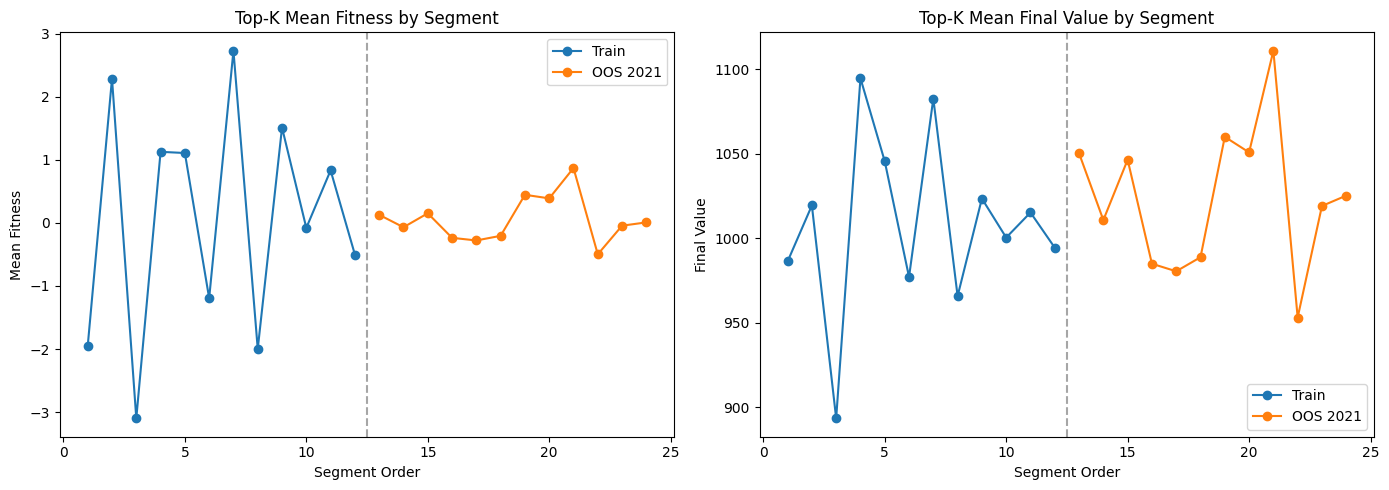

No major alpha decay detected under this segmentation.


In [39]:
# Segment train and 2021 OOS to inspect alpha decay / regime sensitivity
from alphaFactoryLib import compute_decay_summary, normalize_external_frame, split_equal_segments

TRAIN_SEGMENTS = 12
OOS_SEGMENTS = 12
TOP_K_DECAY = 10
OOS_2021_PATH = "jpm_indicators_preprocessed_out_of_sample_2021.csv"


def load_and_preprocess_external(path):
    df_ext = pd.read_csv(path)
    return normalize_external_frame(
        df_ext,
        feature_cols=feature_cols,
        mu=mu,
        sigma=sigma,
        price_col=price_col,
        clip_value=5.0,
    )


def build_segments(df, n_segments, sample_name):
    segments = split_equal_segments(df, n_segments)
    out = []
    for i, seg in enumerate(segments, start=1):
        out.append(
            {
                "sample": sample_name,
                "segment": i,
                "label": f"{sample_name}_{i}",
                "start_row": int(seg.index[0]) if len(seg) > 0 else -1,
                "end_row": int(seg.index[-1]) if len(seg) > 0 else -1,
                "data": seg,
            }
        )
    return out


# Rank programs on full train first
for p in programs:
    train_full_stats = evaluate_program(
        p,
        train,
        signal_fn=sigmoid_framework,
        cost_bps=5,
        slippage_bps=2,
        complexity_lambda=COMPLEXITY_LAMBDA,
    )
    p.set_fitness(train_full_stats["fitness"])

ranked_programs = sorted(programs, key=lambda p: p.fitness, reverse=True)
decay_programs = ranked_programs[:TOP_K_DECAY]

# Load and segment datasets
train_segments = build_segments(train, TRAIN_SEGMENTS, "train")
oos_2021 = load_and_preprocess_external(OOS_2021_PATH)
oos_segments = build_segments(oos_2021, OOS_SEGMENTS, "oos2021")
all_segments = train_segments + oos_segments

# Score top programs on every segment
segment_rows = []
for seg in all_segments:
    for rank, p in enumerate(decay_programs, start=1):
        seg_stats = evaluate_program(
            p,
            seg["data"],
            signal_fn=sigmoid_framework,
            cost_bps=5,
            slippage_bps=2,
            complexity_lambda=COMPLEXITY_LAMBDA,
        )
        segment_rows.append(
            {
                "sample": seg["sample"],
                "segment": seg["segment"],
                "label": seg["label"],
                "rank": rank,
                "program": str(p),
                "fitness": seg_stats["fitness"],
                "raw_fitness": seg_stats["raw_fitness"],
                "final_value": seg_stats["final_value"],
                "moves": seg_stats["moves"],
                "num_steps": seg_stats["num_steps"],
            }
        )

segment_program_results = pd.DataFrame(segment_rows)

segment_summary = (
    segment_program_results.groupby(["sample", "segment", "label"], as_index=False)
    .agg(
        mean_fitness=("fitness", "mean"),
        median_fitness=("fitness", "median"),
        best_fitness=("fitness", "max"),
        mean_final_value=("final_value", "mean"),
        mean_moves=("moves", "mean"),
    )
)

train_summary = segment_summary[segment_summary["sample"] == "train"].copy()
oos_summary = segment_summary[segment_summary["sample"] == "oos2021"].copy()

last_train_mean = train_summary["mean_fitness"].iloc[-1]
first_oos_mean = oos_summary["mean_fitness"].iloc[0]
immediate_regime_gap = first_oos_mean - last_train_mean

train_avg = train_summary["mean_fitness"].mean()
oos_avg = oos_summary["mean_fitness"].mean()
overall_oos_decay = oos_avg - train_avg

decay_metrics = compute_decay_summary(
    train_summary["mean_fitness"].tolist(),
    oos_summary["mean_fitness"].tolist(),
)

alpha_decay_summary = pd.DataFrame(
    [
        {
            "train_mean_fitness_avg": train_avg,
            "last_train_segment_mean": last_train_mean,
            "first_oos_segment_mean": first_oos_mean,
            "immediate_regime_gap": immediate_regime_gap,
            "oos_mean_fitness_avg": oos_avg,
            "overall_oos_decay": overall_oos_decay,
            "library_segment_decay_pct": decay_metrics["segment_decay_pct"],
        }
    ]
)

print("Segment summary across top train performers:")
display(segment_summary)

print("\nDetailed per-program segment results (head):")
display(segment_program_results.head(20))

print("\nAlpha decay summary:")
display(alpha_decay_summary)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(train_summary["segment"], train_summary["mean_fitness"], marker="o", label="Train")
axs[0].plot(oos_summary["segment"] + TRAIN_SEGMENTS, oos_summary["mean_fitness"], marker="o", label="OOS 2021")
axs[0].axvline(TRAIN_SEGMENTS + 0.5, color="gray", linestyle="--", alpha=0.7)
axs[0].set_title("Top-K Mean Fitness by Segment")
axs[0].set_xlabel("Segment Order")
axs[0].set_ylabel("Mean Fitness")
axs[0].legend()

axs[1].plot(train_summary["segment"], train_summary["mean_final_value"], marker="o", label="Train")
axs[1].plot(oos_summary["segment"] + TRAIN_SEGMENTS, oos_summary["mean_final_value"], marker="o", label="OOS 2021")
axs[1].axvline(TRAIN_SEGMENTS + 0.5, color="gray", linestyle="--", alpha=0.7)
axs[1].set_title("Top-K Mean Final Value by Segment")
axs[1].set_xlabel("Segment Order")
axs[1].set_ylabel("Final Value")
axs[1].legend()

plt.tight_layout()
plt.show()

if immediate_regime_gap < -0.05:
    print(
        f"Immediate regime break detected: first OOS segment mean fitness dropped {immediate_regime_gap:.6f} vs last train segment."
    )
elif overall_oos_decay < -0.05:
    print(f"Decay exists, but it is more gradual: average OOS mean fitness is down {overall_oos_decay:.6f} vs train average.")
else:
    print("No major alpha decay detected under this segmentation.")

Inner-train rows: 154 | Validation rows: 39
OOS proxy A rows: 139 | OOS proxy B rows: 139

--- Robust profile: strict ---
ROB Gen 000 | best_rob=-9.555019 best_val=0.422159 valid=0.00 moves=22.9 div=0.97 pat=10
ROB Gen 001 | best_rob=-9.506660 best_val=0.191645 valid=0.00 moves=24.2 div=0.92 pat=10
ROB Gen 002 | best_rob=-9.449922 best_val=0.367582 valid=0.00 moves=21.2 div=0.88 pat=10
ROB Gen 003 | best_rob=-9.496306 best_val=0.077159 valid=0.00 moves=20.7 div=0.89 pat=9
ROB Gen 004 | best_rob=-9.553708 best_val=0.475257 valid=0.00 moves=18.8 div=0.85 pat=8
ROB Gen 005 | best_rob=-9.630282 best_val=0.692144 valid=0.00 moves=22.6 div=0.77 pat=7
ROB Gen 006 | best_rob=-9.501351 best_val=0.442448 valid=0.00 moves=25.9 div=0.82 pat=6
ROB Gen 007 | best_rob=-9.479810 best_val=0.212590 valid=0.00 moves=32.4 div=0.84 pat=5
ROB Gen 008 | best_rob=-9.264582 best_val=0.804886 valid=0.00 moves=32.8 div=0.89 pat=10
ROB Gen 009 | best_rob=-9.381819 best_val=0.543977 valid=0.00 moves=36.6 div=0.90 

,program,expr,robust_fitness,val_fitness,train_fitness,oos_proxy_a_fitness,oos_proxy_b_fitness,passes_gate,generation
0,(stochastic_oscillator / ((donchian_channel_po...,(stochastic_oscillator / ((donchian_channel_po...,-0.014541,-2.461529e-02,-0.118370,0.262585,0.114130,True,2
1,((ADX * ATR) + ((CMF / CMF) / CMF)),((ADX * ATR) + ((CMF / CMF) / CMF)),-0.018258,-3.074106e-02,-0.112198,0.262190,0.114012,True,4
2,(((CMF / OBV) / (z_score / donchian_channel_po...,(((CMF / OBV) / (z_score / donchian_channel_po...,-0.153192,1.356671e-01,-0.251253,0.081715,-0.026199,True,7
3,((z_score / RSI) / ((RSI - ADX) - (z_score - A...,((z_score / RSI) / ((RSI - ADX) - (z_score - A...,-9.295694,8.803650e-07,-0.487064,2.539924,2.336584,False,4
4,((ATR * (stochastic_oscillator + RSI)) * (((bo...,((ATR * (stochastic_oscillator + RSI)) * (((bo...,-9.351875,-5.001310e-01,-0.496749,3.087100,2.856155,False,11
5,((ATR * (stochastic_oscillator + RSI)) * (CMF ...,((ATR * (stochastic_oscillator + RSI)) * (CMF ...,-9.359979,-4.713410e-01,-0.573438,3.076462,2.857587,False,12
6,((ATR * (stochastic_oscillator + RSI)) * (((bo...,((ATR * (stochastic_oscillator + RSI)) * (((bo...,-9.380450,-4.843761e-01,-0.505094,3.065538,2.787861,False,12
7,(((z_score / RSI) * (ATR - bollinger_band_widt...,(((z_score / RSI) * (ATR - bollinger_band_widt...,-9.382425,-3.187651e-01,-0.344292,2.584800,2.364195,False,12
8,(((CMF / OBV) + ADX) / RSI),(((CMF / OBV) + ADX) / RSI),-9.397003,5.167933e-01,-0.735816,1.646554,1.630762,False,4
9,((ATR * ((((bollinger_band_width * ADX) - (ADX...,((ATR * ((((bollinger_band_width * ADX) - (ADX...,-9.401135,-5.642303e-01,-0.650406,3.061162,3.142187,False,11


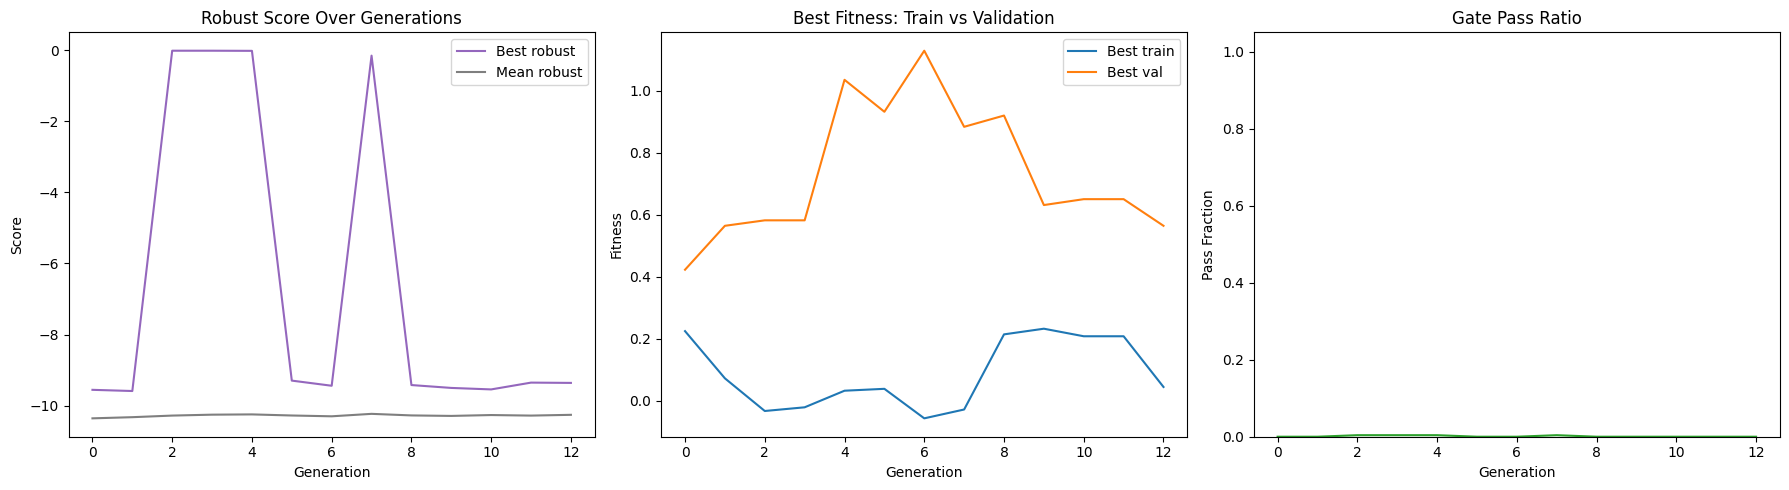

In [40]:
# Early-stopped evolution with robustness gates (anti-overfit + anti-churn)
# Uses time-ordered split of train into inner_train + validation.

from collections import Counter
from dataclasses import replace

from alphaFactoryLib import (
    BACKTEST_COST_BPS,
    BACKTEST_SLIPPAGE_BPS,
    HardGates,
    RobustWeights,
    normalize_external_frame,
    run_robust_evolution,
)

VAL_FRACTION = 0.20
ES_GENERATIONS = GENERATIONS
ES_PATIENCE = 10
HOF_SIZE = 20

# Start strict, then relax if gate pass ratio is effectively zero.
gate_profiles = [
    {
        "name": "strict",
        "weights": RobustWeights(train=0.20, validation=0.45, oos_proxy_a=0.20, oos_proxy_b=0.15),
        "gates": HardGates(
            min_final_value=1000.0,
            max_turnover_ratio=0.55,
            min_validation_fitness=0.01,
            min_oos_proxy_final_value=1000.0,
            max_train_validation_gap=0.10,
            max_validation_oos_gap=0.10,
        ),
    },
    {
        "name": "medium",
        "weights": RobustWeights(train=0.20, validation=0.45, oos_proxy_a=0.20, oos_proxy_b=0.15),
        "gates": HardGates(
            min_final_value=980.0,
            max_turnover_ratio=0.65,
            min_validation_fitness=-0.02,
            min_oos_proxy_final_value=975.0,
            max_train_validation_gap=0.18,
            max_validation_oos_gap=0.18,
        ),
    },
    {
        "name": "relaxed",
        "weights": RobustWeights(train=0.20, validation=0.45, oos_proxy_a=0.20, oos_proxy_b=0.15),
        "gates": HardGates(
            min_final_value=950.0,
            max_turnover_ratio=0.80,
            min_validation_fitness=-0.08,
            min_oos_proxy_final_value=940.0,
            max_train_validation_gap=0.30,
            max_validation_oos_gap=0.30,
        ),
    },
]

EXTRA_TURNOVER_PENALTY = 0.08
TARGET_VALID_RATIO_MEAN = 0.05
TARGET_VALID_RATIO_LAST = 0.02

split_val_idx = int(len(train) * (1.0 - VAL_FRACTION))
inner_train = train.iloc[:split_val_idx].copy()
val_seg = train.iloc[split_val_idx:].copy()

print(f"Inner-train rows: {len(inner_train)} | Validation rows: {len(val_seg)}")

# OOS proxy windows: first and second segments of 2021 to discourage immediate regime-break models
if "oos_2021" not in globals():
    oos_2021_raw = pd.read_csv("jpm_indicators_preprocessed_out_of_sample_2021.csv")
    oos_2021 = normalize_external_frame(
        oos_2021_raw,
        feature_cols=feature_cols,
        mu=mu,
        sigma=sigma,
        price_col=price_col,
        clip_value=5.0,
    )

oos_proxy_len = max(50, len(oos_2021) // 12)
oos_proxy_a = oos_2021.iloc[:oos_proxy_len].copy()
oos_proxy_b = oos_2021.iloc[oos_proxy_len:2 * oos_proxy_len].copy()
if len(oos_proxy_b) == 0:
    oos_proxy_b = oos_proxy_a.copy()

print(f"OOS proxy A rows: {len(oos_proxy_a)} | OOS proxy B rows: {len(oos_proxy_b)}")


def summarize_gate_failures(hist_df):
    counts = Counter()
    if "gate_fail_counts" not in hist_df.columns:
        return counts
    for item in hist_df["gate_fail_counts"]:
        if isinstance(item, dict):
            counts.update({key: int(value) for key, value in item.items() if int(value) > 0})
    return counts


def relax_gate_profile(profile, dominant_reason):
    gates = profile["gates"]
    if dominant_reason in {"min_train_final_value", "min_validation_final_value"}:
        gates = replace(gates, min_final_value=max(900.0, gates.min_final_value - 20.0))
    elif dominant_reason in {"min_oos_proxy_a_final_value", "min_oos_proxy_b_final_value"}:
        gates = replace(gates, min_oos_proxy_final_value=max(900.0, gates.min_oos_proxy_final_value - 20.0))
    elif dominant_reason == "min_validation_fitness":
        gates = replace(gates, min_validation_fitness=gates.min_validation_fitness - 0.02)
    elif dominant_reason == "max_train_validation_gap":
        gates = replace(gates, max_train_validation_gap=gates.max_train_validation_gap + 0.05)
    elif dominant_reason == "max_validation_oos_gap":
        gates = replace(gates, max_validation_oos_gap=gates.max_validation_oos_gap + 0.05)
    elif dominant_reason.startswith("max_turnover_ratio"):
        gates = replace(gates, max_turnover_ratio=min(0.95, gates.max_turnover_ratio + 0.05))
    return {
        "name": f"{profile['name']}+tuned",
        "weights": profile["weights"],
        "gates": gates,
    }


# Fresh population for robust experiments
base_es_programs = []
for i in range(INITIAL_POPULATION):
    d = random.randint(MIN_DEPTH, MAX_DEPTH)
    m = "full" if i % 2 == 0 else "grow"
    base_es_programs.append(build_tree(current_depth=0, max_depth=d, method=m))

profile_runs = []
chosen_profile = None

for profile in gate_profiles:
    print(f"\n--- Robust profile: {profile['name']} ---")

    # Start each profile from the same initial population for fair comparison.
    es_programs = [p.copy() for p in base_es_programs]

    candidate_result = run_robust_evolution(
        programs=es_programs,
        evaluate_program_fn=evaluate_program,
        signal_fn=sigmoid_framework,
        train_df=train,
        test_df=test,
        oos_df=oos_2021,
        inner_train_df=inner_train,
        validation_df=val_seg,
        oos_proxy_a_df=oos_proxy_a,
        oos_proxy_b_df=oos_proxy_b,
        tournament_selection_fn=tournament_selection,
        crossover_fn=crossover,
        mutate_fn=mutate,
        build_tree_fn=build_tree,
        functions_dict=functions,
        operators_list=ops,
        mutation_rate=MUTATION_RATE,
        tournament_size=TOURNAMENT_SIZE,
        immigrant_frac=IMMIGRANT_FRAC,
        min_depth=MIN_DEPTH,
        max_depth=MAX_DEPTH,
        generations=ES_GENERATIONS,
        patience=ES_PATIENCE,
        hall_of_fame_size=HOF_SIZE,
        complexity_lambda=COMPLEXITY_LAMBDA,
        cost_bps=BACKTEST_COST_BPS,
        slippage_bps=BACKTEST_SLIPPAGE_BPS,
        weights=profile["weights"],
        gates=profile["gates"],
        extra_turnover_penalty=EXTRA_TURNOVER_PENALTY,
        verbose=True,
    )

    hist = candidate_result["es_history_df"]
    valid_ratio_mean = float(hist["valid_ratio"].mean()) if len(hist) > 0 else 0.0
    valid_ratio_last = float(hist["valid_ratio"].iloc[-1]) if len(hist) > 0 else 0.0
    oos_final = float(candidate_result["selected_oos_stats"]["final_value"])
    fail_counts = summarize_gate_failures(hist)
    dominant_fail_reason = fail_counts.most_common(1)[0][0] if len(fail_counts) > 0 else None

    print(
        f"Profile summary -> valid_ratio_mean={valid_ratio_mean:.3f}, "
        f"valid_ratio_last={valid_ratio_last:.3f}, selected_oos_final={oos_final:.2f}"
    )
    if len(fail_counts) > 0:
        print("Dominant gate failures:", dict(fail_counts.most_common(5)))

    profile_runs.append(
        {
            "profile": profile["name"],
            "weights": profile["weights"],
            "gates": profile["gates"],
            "result": candidate_result,
            "valid_ratio_mean": valid_ratio_mean,
            "valid_ratio_last": valid_ratio_last,
            "selected_oos_final": oos_final,
            "fail_counts": fail_counts,
            "dominant_fail_reason": dominant_fail_reason,
        }
    )

    if valid_ratio_mean >= TARGET_VALID_RATIO_MEAN and valid_ratio_last >= TARGET_VALID_RATIO_LAST:
        chosen_profile = profile["name"]
        break

# If none reached target pass ratio, pick the profile with best selected OOS final value.
if chosen_profile is None:
    best_run = max(profile_runs, key=lambda r: r["selected_oos_final"])
else:
    best_run = next(r for r in profile_runs if r["profile"] == chosen_profile)

robust_result = best_run["result"]
weights = best_run["weights"]
hard_gates = best_run["gates"]
chosen_gate_profile = best_run["profile"]

# If the selected profile still has a very low pass ratio, relax the two dominant failing gates and rerun.
if best_run["valid_ratio_mean"] <= 0.01 and best_run["dominant_fail_reason"] is not None:
    tuned_profile = {
        "name": f"{best_run['profile']}+tuned",
        "weights": best_run["weights"],
        "gates": best_run["gates"],
    }
    dominant_reasons = [reason for reason, _ in best_run["fail_counts"].most_common(2)]
    for reason in dominant_reasons:
        tuned_profile = relax_gate_profile(tuned_profile, reason)
    print(f"\nRe-running with tuned profile based on dominant gate failures: {dominant_reasons}")

    es_programs = [p.copy() for p in base_es_programs]
    tuned_result = run_robust_evolution(
        programs=es_programs,
        evaluate_program_fn=evaluate_program,
        signal_fn=sigmoid_framework,
        train_df=train,
        test_df=test,
        oos_df=oos_2021,
        inner_train_df=inner_train,
        validation_df=val_seg,
        oos_proxy_a_df=oos_proxy_a,
        oos_proxy_b_df=oos_proxy_b,
        tournament_selection_fn=tournament_selection,
        crossover_fn=crossover,
        mutate_fn=mutate,
        build_tree_fn=build_tree,
        functions_dict=functions,
        operators_list=ops,
        mutation_rate=MUTATION_RATE,
        tournament_size=TOURNAMENT_SIZE,
        immigrant_frac=IMMIGRANT_FRAC,
        min_depth=MIN_DEPTH,
        max_depth=MAX_DEPTH,
        generations=ES_GENERATIONS,
        patience=ES_PATIENCE,
        hall_of_fame_size=HOF_SIZE,
        complexity_lambda=COMPLEXITY_LAMBDA,
        cost_bps=BACKTEST_COST_BPS,
        slippage_bps=BACKTEST_SLIPPAGE_BPS,
        weights=tuned_profile["weights"],
        gates=tuned_profile["gates"],
        extra_turnover_penalty=EXTRA_TURNOVER_PENALTY,
        verbose=True,
    )

    tuned_hist = tuned_result["es_history_df"]
    tuned_valid_ratio_mean = float(tuned_hist["valid_ratio"].mean()) if len(tuned_hist) > 0 else 0.0
    tuned_valid_ratio_last = float(tuned_hist["valid_ratio"].iloc[-1]) if len(tuned_hist) > 0 else 0.0
    tuned_oos_final = float(tuned_result["selected_oos_stats"]["final_value"])
    tuned_fail_counts = summarize_gate_failures(tuned_hist)
    tuned_dominant_fail_reason = tuned_fail_counts.most_common(1)[0][0] if len(tuned_fail_counts) > 0 else None
    print(
        f"Tuned profile summary -> valid_ratio_mean={tuned_valid_ratio_mean:.3f}, "
        f"valid_ratio_last={tuned_valid_ratio_last:.3f}, selected_oos_final={tuned_oos_final:.2f}"
    )
    if len(tuned_fail_counts) > 0:
        print("Tuned dominant gate failures:", dict(tuned_fail_counts.most_common(5)))

    if (
        tuned_valid_ratio_mean > best_run["valid_ratio_mean"]
        or (tuned_valid_ratio_mean == best_run["valid_ratio_mean"] and tuned_oos_final >= best_run["selected_oos_final"])
    ):
        robust_result = tuned_result
        weights = tuned_profile["weights"]
        hard_gates = tuned_profile["gates"]
        chosen_gate_profile = tuned_profile["name"]
        best_run = {
            "profile": tuned_profile["name"],
            "weights": tuned_profile["weights"],
            "gates": tuned_profile["gates"],
            "result": tuned_result,
            "valid_ratio_mean": tuned_valid_ratio_mean,
            "valid_ratio_last": tuned_valid_ratio_last,
            "selected_oos_final": tuned_oos_final,
            "fail_counts": tuned_fail_counts,
            "dominant_fail_reason": tuned_dominant_fail_reason,
        }

best_program_es = robust_result["best_program"]
best_gen = robust_result["best_generation"]
best_robust_seen = robust_result["best_robust_score"]
es_history_df = robust_result["es_history_df"]
hall_of_fame = robust_result["hall_of_fame"]

# Final chosen model from robust validation-driven evolution
selected_program = best_program_es
selected_train_stats = robust_result["selected_train_stats"]
selected_test_stats = robust_result["selected_test_stats"]
selected_oos_2021_stats = robust_result["selected_oos_stats"]

print("\nChosen robust profile:", chosen_gate_profile)
print("Selected robust program:")
print(selected_program)
print("\nSelected TRAIN stats:", selected_train_stats)
print("Selected TEST stats :", selected_test_stats)
print("Selected OOS 2021 stats:", selected_oos_2021_stats)
print("\nBest robust generation:", best_gen)
print("Best robust score:", best_robust_seen)

print("\nGeneralization diagnostics:")
print(f"Train - Test fitness gap: {selected_train_stats['fitness'] - selected_test_stats['fitness']:.6f}")
print(f"Train - OOS fitness gap : {selected_train_stats['fitness'] - selected_oos_2021_stats['fitness']:.6f}")
print(f"Test final value: {selected_test_stats['final_value']:.2f}")
print(f"OOS final value : {selected_oos_2021_stats['final_value']:.2f}")

hof_df = pd.DataFrame(hall_of_fame)
print("\nHall-of-fame unique expressions (top 10):")
display(hof_df.head(10))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].plot(es_history_df["generation"], es_history_df["best_robust"], label="Best robust", color="tab:purple")
axs[0].plot(es_history_df["generation"], es_history_df["mean_robust"], label="Mean robust", color="tab:gray")
axs[0].set_title("Robust Score Over Generations")
axs[0].set_xlabel("Generation")
axs[0].set_ylabel("Score")
axs[0].legend()

axs[1].plot(es_history_df["generation"], es_history_df["best_train"], label="Best train", color="tab:blue")
axs[1].plot(es_history_df["generation"], es_history_df["best_val"], label="Best val", color="tab:orange")
axs[1].set_title("Best Fitness: Train vs Validation")
axs[1].set_xlabel("Generation")
axs[1].set_ylabel("Fitness")
axs[1].legend()

axs[2].plot(es_history_df["generation"], es_history_df["valid_ratio"], color="tab:green")
axs[2].set_title("Gate Pass Ratio")
axs[2].set_xlabel("Generation")
axs[2].set_ylabel("Pass Fraction")
axs[2].set_ylim(0.0, 1.05)

plt.tight_layout()
plt.show()


In [41]:
# Compare baseline-selected vs robust-selected program in one place

if "best_program" not in globals():
    raise RuntimeError("Run the baseline selection cells first to create best_program.")
if "selected_program" not in globals():
    raise RuntimeError("Run the robust selection cell first to create selected_program.")
if "oos_2021" not in globals():
    raise RuntimeError("Run OOS preparation cells first so oos_2021 exists.")


def _eval_all(p):
    tr = evaluate_program(
        p,
        train,
        signal_fn=sigmoid_framework,
        cost_bps=5,
        slippage_bps=2,
        complexity_lambda=COMPLEXITY_LAMBDA,
    )
    te = evaluate_program(
        p,
        test,
        signal_fn=sigmoid_framework,
        cost_bps=5,
        slippage_bps=2,
        complexity_lambda=COMPLEXITY_LAMBDA,
    )
    oo = evaluate_program(
        p,
        oos_2021,
        signal_fn=sigmoid_framework,
        cost_bps=5,
        slippage_bps=2,
        complexity_lambda=COMPLEXITY_LAMBDA,
    )
    return tr, te, oo


def _buy_hold_stats(df, price_col="price", initial_value=1000.0):
    if len(df) == 0:
        return {
            "final_value": float(initial_value),
            "ret_pct": 0.0,
            "num_steps": 0,
            "start_price": np.nan,
            "end_price": np.nan,
            "valid_price_rows": 0,
        }

    px = pd.to_numeric(df[price_col], errors="coerce")
    px = px.replace([np.inf, -np.inf], np.nan).dropna()
    px = px[px > 0]

    if len(px) < 2:
        return {
            "final_value": float(initial_value),
            "ret_pct": 0.0,
            "num_steps": int(len(df)),
            "start_price": float(px.iloc[0]) if len(px) == 1 else np.nan,
            "end_price": float(px.iloc[0]) if len(px) == 1 else np.nan,
            "valid_price_rows": int(len(px)),
        }

    p0 = float(px.iloc[0])
    p1 = float(px.iloc[-1])
    final_value = float(initial_value) * (p1 / p0)

    return {
        "final_value": float(final_value),
        "ret_pct": float((final_value / initial_value - 1.0) * 100.0),
        "num_steps": int(len(df)),
        "start_price": p0,
        "end_price": p1,
        "valid_price_rows": int(len(px)),
    }


base_train, base_test, base_oos = _eval_all(best_program)
rob_train, rob_test, rob_oos = _eval_all(selected_program)

bh_train = _buy_hold_stats(train, price_col=price_col)
bh_test = _buy_hold_stats(test, price_col=price_col)
bh_oos = _buy_hold_stats(oos_2021, price_col=price_col)

comparison_df = pd.DataFrame(
    [
        {
            "selector": "baseline_train_best",
            "train_fitness": base_train["fitness"],
            "test_fitness": base_test["fitness"],
            "oos_fitness": base_oos["fitness"],
            "train_final": base_train["final_value"],
            "test_final": base_test["final_value"],
            "oos_final": base_oos["final_value"],
            "train_test_gap": base_train["fitness"] - base_test["fitness"],
            "train_oos_gap": base_train["fitness"] - base_oos["fitness"],
            "moves_train": base_train["moves"],
        },
        {
            "selector": "robust_selected",
            "train_fitness": rob_train["fitness"],
            "test_fitness": rob_test["fitness"],
            "oos_fitness": rob_oos["fitness"],
            "train_final": rob_train["final_value"],
            "test_final": rob_test["final_value"],
            "oos_final": rob_oos["final_value"],
            "train_test_gap": rob_train["fitness"] - rob_test["fitness"],
            "train_oos_gap": rob_train["fitness"] - rob_oos["fitness"],
            "moves_train": rob_train["moves"],
        },
        {
            "selector": "buy_and_hold",
            "train_fitness": np.nan,
            "test_fitness": np.nan,
            "oos_fitness": np.nan,
            "train_final": bh_train["final_value"],
            "test_final": bh_test["final_value"],
            "oos_final": bh_oos["final_value"],
            "train_test_gap": np.nan,
            "train_oos_gap": np.nan,
            "moves_train": 1,
        },
    ]
)

buy_hold_row = comparison_df[comparison_df["selector"] == "buy_and_hold"].iloc[0]
comparison_df["oos_alpha_vs_buy_hold"] = comparison_df["oos_final"] - float(buy_hold_row["oos_final"])
comparison_df["test_alpha_vs_buy_hold"] = comparison_df["test_final"] - float(buy_hold_row["test_final"])
comparison_df["train_alpha_vs_buy_hold"] = comparison_df["train_final"] - float(buy_hold_row["train_final"])

display(comparison_df)

print("Baseline expression:")
print(best_program)
print("\nRobust-selected expression:")
print(selected_program)
print("\nBuy and hold snapshot:")
print(
    f"Train final={bh_train['final_value']:.2f} ({bh_train['ret_pct']:.2f}%), "
    f"Test final={bh_test['final_value']:.2f} ({bh_test['ret_pct']:.2f}%), "
    f"OOS final={bh_oos['final_value']:.2f} ({bh_oos['ret_pct']:.2f}%)"
)
print(
    f"B&H valid positive prices -> train={bh_train['valid_price_rows']}, "
    f"test={bh_test['valid_price_rows']}, oos={bh_oos['valid_price_rows']}"
)
print(
    f"B&H anchor prices -> oos start={bh_oos['start_price']:.4f}, "
    f"oos end={bh_oos['end_price']:.4f}"
)

,selector,train_fitness,test_fitness,oos_fitness,train_final,test_final,oos_final,train_test_gap,train_oos_gap,moves_train,oos_alpha_vs_buy_hold,test_alpha_vs_buy_hold,train_alpha_vs_buy_hold
0,baseline_train_best,0.087163,0.681761,-0.044683,1114.959841,1079.590004,1055.198842,-0.594598,0.131846,140,-194.730349,-340.994159,387.504781
1,robust_selected,-0.080338,1.772148,-0.092417,1003.527229,1184.774500,1028.022078,-1.852486,0.012080,29,-221.907113,-235.809663,276.072170
2,buy_and_hold,NaN,NaN,NaN,727.455060,1420.584163,1249.929191,NaN,NaN,1,0.000000,0.000000,0.000000


Baseline expression:
(((bollinger_band_width * (ADX / RSI)) - ((stochastic_oscillator - ADX) / (SMA * SMA))) * (((CMF - RSI) / (ADX - z_score)) / ((stochastic_oscillator - stochastic_oscillator) + (OBV * stochastic_oscillator))))

Robust-selected expression:
(stochastic_oscillator / ((donchian_channel_position * CMF) / (donchian_channel_position / stochastic_oscillator)))

Buy and hold snapshot:
Train final=727.46 (-27.25%), Test final=1420.58 (42.06%), OOS final=1249.93 (24.99%)
B&H valid positive prices -> train=192, test=84, oos=1668
B&H anchor prices -> oos start=115.5842, oos end=144.4721


In [42]:
# Buy-and-hold benchmark sanity check: endpoint-flat vs path-flat

def _benchmark_path_stats(df, label, price_col="price", initial_value=1000.0):
    if len(df) == 0:
        return {
            "sample": label,
            "rows": 0,
            "start_price": np.nan,
            "end_price": np.nan,
            "min_price": np.nan,
            "max_price": np.nan,
            "end_return_pct": np.nan,
            "range_pct": np.nan,
            "path_flag": "empty",
        }

    px_all = pd.to_numeric(df[price_col], errors="coerce")
    px_all = px_all.replace([np.inf, -np.inf], np.nan).dropna()
    px_pos = px_all[px_all > 0]

    if len(px_pos) < 2:
        return {
            "sample": label,
            "rows": int(len(df)),
            "start_price": float(px_pos.iloc[0]) if len(px_pos) == 1 else np.nan,
            "end_price": float(px_pos.iloc[0]) if len(px_pos) == 1 else np.nan,
            "min_price": float(px_all.min()) if len(px_all) > 0 else np.nan,
            "max_price": float(px_all.max()) if len(px_all) > 0 else np.nan,
            "end_return_pct": np.nan,
            "range_pct": np.nan,
            "path_flag": "insufficient_positive_prices",
        }

    p0 = float(px_pos.iloc[0])
    p1 = float(px_pos.iloc[-1])
    pmin = float(px_pos.min())
    pmax = float(px_pos.max())

    end_return_pct = (p1 / p0 - 1.0) * 100.0
    range_pct = (pmax / pmin - 1.0) * 100.0

    is_endpoint_flat = abs(end_return_pct) < 1e-10
    is_path_flat = abs(range_pct) < 1e-10

    if is_path_flat:
        path_flag = "path_flat"
    elif is_endpoint_flat:
        path_flag = "round_trip_to_start"
    else:
        path_flag = "trending_or_drifting"

    return {
        "sample": label,
        "rows": int(len(df)),
        "start_price": p0,
        "end_price": p1,
        "min_price": pmin,
        "max_price": pmax,
        "end_return_pct": float(end_return_pct),
        "range_pct": float(range_pct),
        "path_flag": path_flag,
    }


benchmark_path_df = pd.DataFrame(
    [
        _benchmark_path_stats(train, "train", price_col=price_col),
        _benchmark_path_stats(test, "test", price_col=price_col),
        _benchmark_path_stats(oos_2021, "oos2021", price_col=price_col),
    ]
)

display(benchmark_path_df)

oos_row = benchmark_path_df[benchmark_path_df["sample"] == "oos2021"].iloc[0]
print(
    f"OOS benchmark sanity: end_return={oos_row['end_return_pct']:.4f}% | "
    f"range={oos_row['range_pct']:.4f}% | path_flag={oos_row['path_flag']}"
)
if oos_row["path_flag"] == "round_trip_to_start":
    print("Interpretation: OOS buy-and-hold ended flat, but prices moved intraperiod.")
elif oos_row["path_flag"] == "path_flat":
    print("Interpretation: OOS price path itself is flat, so buy-and-hold is structurally flat.")
elif oos_row["path_flag"] == "insufficient_positive_prices":
    print("Interpretation: OOS has insufficient positive prices; inspect preprocessing before using benchmark.")
else:
    print("Interpretation: OOS buy-and-hold has directional movement in this window.")

,sample,rows,start_price,end_price,min_price,max_price,end_return_pct,range_pct,path_flag
0,train,193,125.020370,90.946701,70.478371,125.020370,-27.254494,77.388281,trending_or_drifting
1,test,84,90.010056,127.866859,88.651001,130.567551,42.058416,47.282658,trending_or_drifting
2,oos2021,1669,115.584221,144.472092,115.584221,161.703873,24.992919,39.901339,trending_or_drifting


OOS benchmark sanity: end_return=24.9929% | range=39.9013% | path_flag=trending_or_drifting
Interpretation: OOS buy-and-hold has directional movement in this window.


## Baseline vs Robust Selection

This notebook runs two different model-selection procedures:

1. Baseline evolution (earlier cells): picks the best expression by train-driven fitness.
2. Robust evolution (this section): picks by a composite robust score using validation and OOS proxy gates.

These can and often should return different expressions.

,sample,segment,start,end,ret_pct,max_drawdown_pct
0,train,1,1000.0,974.454619,-2.554538,2.554538
1,train,2,1000.0,1004.341008,0.434101,1.298850
2,train,3,1000.0,857.260881,-14.273912,15.472627
3,train,4,1000.0,990.000595,-0.999941,7.557030
4,train,5,1000.0,1031.639454,3.163945,7.733368
5,train,6,1000.0,952.785625,-4.721438,7.306517
6,train,7,1000.0,1041.124322,4.112432,7.318115
7,train,8,1000.0,973.924809,-2.607519,4.673884
8,train,9,1000.0,1021.597911,2.159791,1.552383
9,train,10,1000.0,1015.904119,1.590412,1.891296


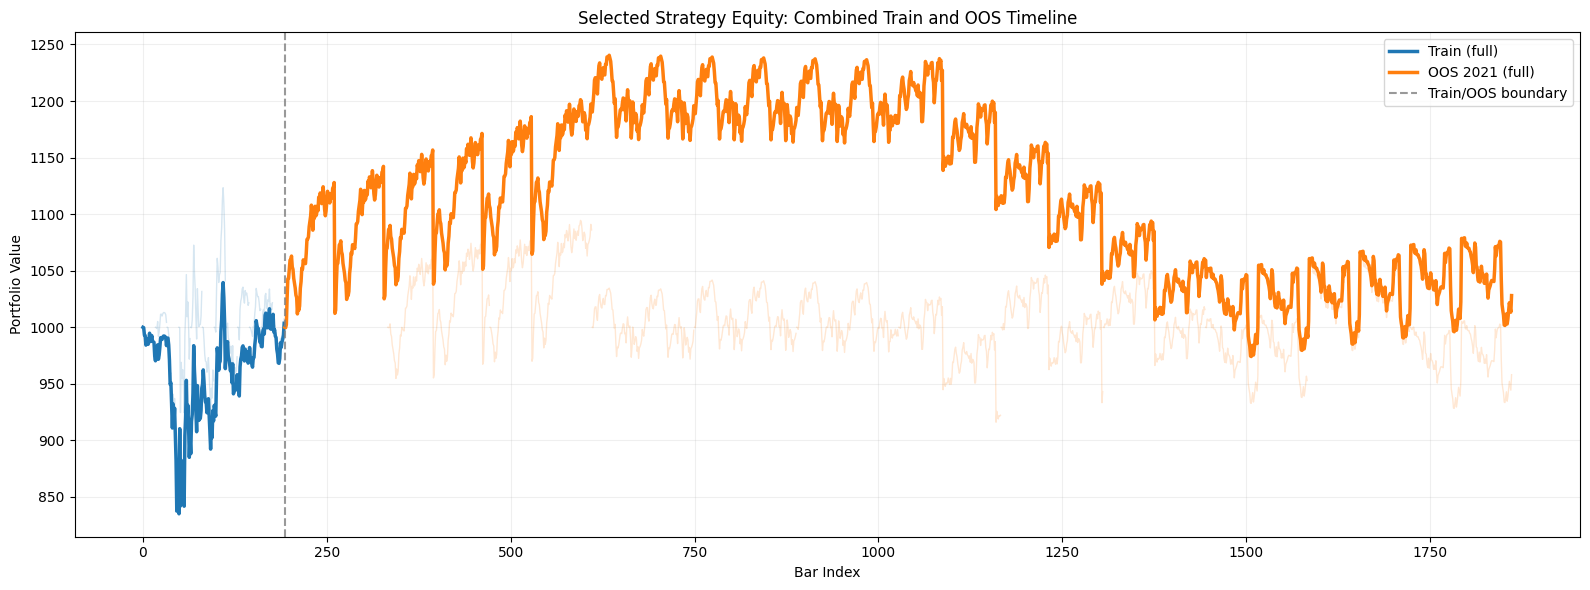

Train bars: 193 | OOS bars: 1669 | Combined bars: 1862
If this is larger than expected, the source CSV likely contains intraday or duplicate-period rows.
Mean train segment return %: -0.898
Mean OOS 2021 segment return %: -0.429
Segment return decay (OOS - train): 0.468
Mean train segment max drawdown %: 5.176
Mean OOS segment max drawdown %: 8.353


In [43]:
# Per-segment equity curves for selected robust program

from alphaFactoryLib import equity_curve_for_program, max_drawdown_pct, split_df_segments

if "selected_program" not in globals():
    raise RuntimeError("Run the robust selection cell first to create selected_program.")

train_seg_curves = split_df_segments(train, 12)
oos_seg_curves = split_df_segments(oos_2021, 12)

train_seg_summary = []
for seg_i, seg_df in train_seg_curves:
    c = equity_curve_for_program(
        selected_program,
        seg_df,
        sigmoid_framework,
        price_col=price_col,
        cost_bps=5,
        slippage_bps=2,
    )
    train_seg_summary.append(
        {
            "sample": "train",
            "segment": seg_i,
            "start": float(c[0]),
            "end": float(c[-1]),
            "ret_pct": float((c[-1] / c[0] - 1.0) * 100.0) if c[0] > 0 else np.nan,
            "max_drawdown_pct": max_drawdown_pct(c),
        }
    )

oos_seg_summary = []
for seg_i, seg_df in oos_seg_curves:
    c = equity_curve_for_program(
        selected_program,
        seg_df,
        sigmoid_framework,
        price_col=price_col,
        cost_bps=5,
        slippage_bps=2,
    )
    oos_seg_summary.append(
        {
            "sample": "oos2021",
            "segment": seg_i,
            "start": float(c[0]),
            "end": float(c[-1]),
            "ret_pct": float((c[-1] / c[0] - 1.0) * 100.0) if c[0] > 0 else np.nan,
            "max_drawdown_pct": max_drawdown_pct(c),
        }
    )

seg_equity_df = pd.DataFrame(train_seg_summary + oos_seg_summary)
display(seg_equity_df)

# Combined train -> OOS view for the same selected strategy
train_full_curve = equity_curve_for_program(
    selected_program,
    train,
    sigmoid_framework,
    price_col=price_col,
    cost_bps=5,
    slippage_bps=2,
)
oos_full_curve = equity_curve_for_program(
    selected_program,
    oos_2021,
    sigmoid_framework,
    price_col=price_col,
    cost_bps=5,
    slippage_bps=2,
)

# Use bar-count indexing (rows in the dataset), not curve-point count.
# equity_curve_for_program returns len(data)+1 due initial starting value.
train_bars = len(train)
oos_bars = len(oos_2021)

x_train = np.arange(train_bars)
x_oos = np.arange(oos_bars) + train_bars

train_full_curve_plot = train_full_curve[1:]
oos_full_curve_plot = oos_full_curve[1:]

fig, ax = plt.subplots(figsize=(16, 6))

# Light per-segment traces aligned to true bar counts
offset = 0
for _, seg_df in train_seg_curves:
    c = equity_curve_for_program(
        selected_program,
        seg_df,
        sigmoid_framework,
        price_col=price_col,
        cost_bps=5,
        slippage_bps=2,
    )
    seg_len = len(seg_df)
    x = np.arange(seg_len) + offset
    ax.plot(x, c[1:], color="tab:blue", alpha=0.18, linewidth=1)
    offset += seg_len

for _, seg_df in oos_seg_curves:
    c = equity_curve_for_program(
        selected_program,
        seg_df,
        sigmoid_framework,
        price_col=price_col,
        cost_bps=5,
        slippage_bps=2,
    )
    seg_len = len(seg_df)
    x = np.arange(seg_len) + offset
    ax.plot(x, c[1:], color="tab:orange", alpha=0.18, linewidth=1)
    offset += seg_len

# Main full-dataset curves
ax.plot(x_train, train_full_curve_plot, color="tab:blue", linewidth=2.5, label="Train (full)")
ax.plot(x_oos, oos_full_curve_plot, color="tab:orange", linewidth=2.5, label="OOS 2021 (full)")

split_x = train_bars
ax.axvline(split_x, color="gray", linestyle="--", alpha=0.8, label="Train/OOS boundary")
ax.set_title("Selected Strategy Equity: Combined Train and OOS Timeline")
ax.set_xlabel("Bar Index")
ax.set_ylabel("Portfolio Value")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Train bars: {train_bars} | OOS bars: {oos_bars} | Combined bars: {train_bars + oos_bars}")
print("If this is larger than expected, the source CSV likely contains intraday or duplicate-period rows.")

train_mean_seg_ret = seg_equity_df[seg_equity_df["sample"] == "train"]["ret_pct"].mean()
oos_mean_seg_ret = seg_equity_df[seg_equity_df["sample"] == "oos2021"]["ret_pct"].mean()
train_mean_seg_dd = seg_equity_df[seg_equity_df["sample"] == "train"]["max_drawdown_pct"].mean()
oos_mean_seg_dd = seg_equity_df[seg_equity_df["sample"] == "oos2021"]["max_drawdown_pct"].mean()

print(f"Mean train segment return %: {train_mean_seg_ret:.3f}")
print(f"Mean OOS 2021 segment return %: {oos_mean_seg_ret:.3f}")
print(f"Segment return decay (OOS - train): {oos_mean_seg_ret - train_mean_seg_ret:.3f}")
print(f"Mean train segment max drawdown %: {train_mean_seg_dd:.3f}")
print(f"Mean OOS segment max drawdown %: {oos_mean_seg_dd:.3f}")

In [44]:
# Persistent experiment summary log (run this after robust + segment cells)

from alphaFactoryLib import append_experiment_log

if "selected_program" not in globals():
    raise RuntimeError("Run robust selection cell first.")

if "seg_equity_df" not in globals():
    raise RuntimeError("Run per-segment equity cell first.")

run_row = {
    "timestamp": pd.Timestamp.now(),
    "generations": GENERATIONS,
    "max_depth": MAX_DEPTH,
    "patience": ES_PATIENCE,
    "best_gen": best_gen if "best_gen" in globals() else np.nan,
    "best_robust": best_robust_seen if "best_robust_seen" in globals() else np.nan,
    "valid_ratio_last": float(es_history_df["valid_ratio"].iloc[-1]) if "es_history_df" in globals() and len(es_history_df) > 0 else np.nan,
    "train_fitness": selected_train_stats["fitness"],
    "test_fitness": selected_test_stats["fitness"],
    "oos_fitness": selected_oos_2021_stats["fitness"],
    "train_final": selected_train_stats["final_value"],
    "test_final": selected_test_stats["final_value"],
    "oos_final": selected_oos_2021_stats["final_value"],
    "train_seg_ret_mean_pct": float(seg_equity_df[seg_equity_df["sample"] == "train"]["ret_pct"].mean()),
    "oos_seg_ret_mean_pct": float(seg_equity_df[seg_equity_df["sample"] == "oos2021"]["ret_pct"].mean()),
    "seg_decay_oos_minus_train_pct": float(
        seg_equity_df[seg_equity_df["sample"] == "oos2021"]["ret_pct"].mean()
        - seg_equity_df[seg_equity_df["sample"] == "train"]["ret_pct"].mean()
    ),
    "program": str(selected_program),
}

experiment_log_df = append_experiment_log(
    experiment_log_df if "experiment_log_df" in globals() else None,
    run_label=f"run_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}",
    selected_expression=str(selected_program),
    train_stats=selected_train_stats,
    test_stats=selected_test_stats,
    oos_stats=selected_oos_2021_stats,
    best_generation=best_gen if "best_gen" in globals() else None,
    best_robust_score=best_robust_seen if "best_robust_seen" in globals() else None,
)

# Keep legacy notebook columns for continuity
for col, val in run_row.items():
    experiment_log_df.loc[experiment_log_df.index[-1], col] = val

# Keep newest at top
experiment_log_df = experiment_log_df.sort_values("timestamp", ascending=False).reset_index(drop=True)

print(f"Logged runs: {len(experiment_log_df)}")

display_cols = [
    "timestamp",
    "generations",
    "max_depth",
    "best_gen",
    "best_robust",
    "valid_ratio_last",
    "train_fitness",
    "test_fitness",
    "oos_fitness",
    "train_final",
    "test_final",
    "oos_final",
    "train_seg_ret_mean_pct",
    "oos_seg_ret_mean_pct",
    "seg_decay_oos_minus_train_pct",
]

display(experiment_log_df[display_cols])

print("Latest selected program:")
print(experiment_log_df.loc[0, "program"])

Logged runs: 2


,timestamp,generations,max_depth,best_gen,best_robust,valid_ratio_last,train_fitness,test_fitness,oos_fitness,train_final,test_final,oos_final,train_seg_ret_mean_pct,oos_seg_ret_mean_pct,seg_decay_oos_minus_train_pct
0,2026-06-02 12:52:34.307000,25.0,4.0,2.0,-0.014541,0.0,-0.080338,1.772148,-0.092417,1003.527229,1184.774500,1028.022078,-0.897749,-0.429351,0.468398
1,2026-06-02 12:41:25.104639,25.0,4.0,19.0,-0.110858,0.0,0.074758,1.678931,-0.022784,1059.310402,1178.602939,1170.667373,-0.708419,0.559298,1.267717


Latest selected program:
(stochastic_oscillator / ((donchian_channel_position * CMF) / (donchian_channel_position / stochastic_oscillator)))


In [47]:
# Compact run diagnostics snapshot

from collections import Counter

import pandas as pd

if "bh_oos" not in globals():
    _px = pd.to_numeric(oos_2021[price_col], errors="coerce") if len(oos_2021) > 0 else pd.Series(dtype=float)
    _px = _px.replace([np.inf, -np.inf], np.nan).dropna()
    _px = _px[_px > 0]
    if len(_px) >= 2:
        _tmp_final = 1000.0 * (float(_px.iloc[-1]) / float(_px.iloc[0]))
    else:
        _tmp_final = 1000.0
    bh_oos = {"final_value": float(_tmp_final)}

_gate_fail_summary = Counter()
if "es_history_df" in globals() and "gate_fail_counts" in es_history_df.columns:
    for item in es_history_df["gate_fail_counts"]:
        if isinstance(item, dict):
            _gate_fail_summary.update({key: int(value) for key, value in item.items() if int(value) > 0})

diag = {
    "chosen_gate_profile": chosen_gate_profile if "chosen_gate_profile" in globals() else "n/a",
    "baseline_train_fitness": float(base_train["fitness"]) if "base_train" in globals() else float("nan"),
    "baseline_test_fitness": float(base_test["fitness"]) if "base_test" in globals() else float("nan"),
    "baseline_oos_fitness": float(base_oos["fitness"]) if "base_oos" in globals() else float("nan"),
    "baseline_oos_final": float(base_oos["final_value"]) if "base_oos" in globals() else float("nan"),
    "robust_train_fitness": float(rob_train["fitness"]) if "rob_train" in globals() else float("nan"),
    "robust_test_fitness": float(rob_test["fitness"]) if "rob_test" in globals() else float("nan"),
    "robust_oos_fitness": float(rob_oos["fitness"]) if "rob_oos" in globals() else float("nan"),
    "robust_oos_final": float(rob_oos["final_value"]) if "rob_oos" in globals() else float("nan"),
    "buy_hold_oos_final": float(bh_oos["final_value"]),
    "baseline_oos_alpha_vs_buy_hold": float(base_oos["final_value"] - bh_oos["final_value"]) if "base_oos" in globals() else float("nan"),
    "robust_oos_alpha_vs_buy_hold": float(rob_oos["final_value"] - bh_oos["final_value"]) if "rob_oos" in globals() else float("nan"),
    "train_bars": int(train_bars) if "train_bars" in globals() else int(len(train)),
    "oos_bars": int(oos_bars) if "oos_bars" in globals() else int(len(oos_2021)),
    "combined_bars": int((train_bars + oos_bars) if "train_bars" in globals() and "oos_bars" in globals() else (len(train) + len(oos_2021))),
    "robust_best_score_seen": float(best_robust_seen) if "best_robust_seen" in globals() else float("nan"),
    "robust_valid_ratio_last": float(es_history_df["valid_ratio"].iloc[-1]) if "es_history_df" in globals() and len(es_history_df) > 0 else float("nan"),
    "robust_valid_ratio_mean": float(es_history_df["valid_ratio"].mean()) if "es_history_df" in globals() and len(es_history_df) > 0 else float("nan"),
    "robust_best_val_peak": float(es_history_df["best_val"].max()) if "es_history_df" in globals() and len(es_history_df) > 0 else float("nan"),
    "baseline_best_val_peak": float(history_df["best_val_fitness"].max()) if "history_df" in globals() and "best_val_fitness" in history_df.columns else float("nan"),
    "baseline_mean_nodes_last": float(history_df["mean_nodes"].iloc[-1]) if "history_df" in globals() and "mean_nodes" in history_df.columns else float("nan"),
    "dominant_gate_failures": dict(_gate_fail_summary.most_common(8)),
}

diag_df = pd.DataFrame([diag]).T.reset_index()
diag_df.columns = ["metric", "value"]
display(diag_df)

if "base_oos" in globals() and "rob_oos" in globals():
    print("\nOOS final value delta (robust - baseline):", float(rob_oos["final_value"] - base_oos["final_value"]))
    print("OOS fitness delta (robust - baseline):", float(rob_oos["fitness"] - base_oos["fitness"]))

if "base_oos" in globals() and "rob_oos" in globals():
    print("\nBenchmark check vs buy-and-hold (OOS final value deltas):")
    print("Baseline alpha vs buy-and-hold:", float(base_oos["final_value"] - bh_oos["final_value"]))
    print("Robust alpha vs buy-and-hold:", float(rob_oos["final_value"] - bh_oos["final_value"]))

if "es_history_df" in globals() and len(es_history_df) > 0:
    print("\nRobust gate pass ratios:")
    print(es_history_df[["generation", "valid_ratio"]])
    if len(_gate_fail_summary) > 0:
        print("\nDominant robust gate failures:")
        print(dict(_gate_fail_summary.most_common(8)))


,metric,value
0,chosen_gate_profile,medium+tuned+tuned+tuned
1,baseline_train_fitness,0.087163
2,baseline_test_fitness,0.681761
3,baseline_oos_fitness,-0.044683
4,baseline_oos_final,1055.198842
5,robust_train_fitness,-0.080338
6,robust_test_fitness,1.772148
7,robust_oos_fitness,-0.092417
8,robust_oos_final,1028.022078
9,buy_hold_oos_final,1249.929191



OOS final value delta (robust - baseline): -27.176763903273013
OOS fitness delta (robust - baseline): -0.04773475450351002

Benchmark check vs buy-and-hold (OOS final value deltas):
Baseline alpha vs buy-and-hold: -194.73034894474927
Robust alpha vs buy-and-hold: -221.90711284802228

Robust gate pass ratios:
    generation  valid_ratio
0            0        0.000
1            1        0.000
2            2        0.004
3            3        0.004
4            4        0.004
5            5        0.000
6            6        0.000
7            7        0.004
8            8        0.000
9            9        0.000
10          10        0.000
11          11        0.000
12          12        0.000

Dominant robust gate failures:
{'min_train_final_value': 3144, 'min_validation_fitness': 3120, 'max_turnover_ratio_oos_proxy_b': 465, 'max_train_validation_gap': 271, 'max_turnover_ratio_oos_proxy_a': 262, 'min_oos_proxy_b_final_value': 210, 'min_oos_proxy_a_final_value': 141, 'max_turnover_rati

## Project Postmortem and Reusable Gate-Passing Pattern

This section closes the experiment and documents the gate-passing system in a reusable way.

### What the passing system does

For each candidate strategy in each generation:
1. Compute train, validation, and OOS-proxy metrics.
2. Apply hard gates (must-pass constraints).
3. Mark candidate as valid if all gates pass.
4. Build generation-level pass ratio = valid candidates / total candidates.
5. Use robust score to rank only among feasible candidates, or fall back to least-bad candidates when feasibility is sparse.

### Why pass ratio matters

Pass ratio is a health metric for your search space constraints.
- Too low: constraints are over-tight and search collapses to noise-level feasible pockets.
- Too high: constraints are too loose and admit fragile/overfit candidates.

A practical target is a band, not a single point. Example: 3% to 15%.

### Tighten vs Relax (band controller concept)

Instead of always relaxing when pass ratio is low, drive constraints toward a target band:
- If pass ratio < lower bound: relax dominant failing gates.
- If pass ratio > upper bound: tighten weakly binding gates.
- If inside band: keep gates unchanged (or only minor smoothing).

This makes the controller transferable to any constrained search workflow:
- strategy selection
- hyperparameter optimization
- model governance thresholding
- quality gates in automated pipelines

In [46]:
# Postmortem snapshot + reusable pass-ratio band controller template

from dataclasses import replace
from typing import Dict, Tuple

import pandas as pd


def summarize_project_postmortem():
    rows = []

    if "comparison_df" in globals():
        cmp = comparison_df.copy()
        for _, r in cmp.iterrows():
            rows.append(
                {
                    "selector": r.get("selector"),
                    "oos_final": float(r.get("oos_final", float("nan"))),
                    "oos_alpha_vs_buy_hold": float(r.get("oos_alpha_vs_buy_hold", float("nan"))),
                    "test_alpha_vs_buy_hold": float(r.get("test_alpha_vs_buy_hold", float("nan"))),
                }
            )

    if not rows:
        print("Run the comparison cell first to populate postmortem summary.")
        return

    out = pd.DataFrame(rows).sort_values("oos_alpha_vs_buy_hold", ascending=False)
    display(out)

    non_bh = out[out["selector"] != "buy_and_hold"].copy()
    if len(non_bh) > 0:
        best = non_bh.iloc[0]
        print(
            f"Best OOS alpha vs buy-and-hold: {best['selector']} -> "
            f"{best['oos_alpha_vs_buy_hold']:.6f}"
        )

    if "es_history_df" in globals() and len(es_history_df) > 0:
        vr_last = float(es_history_df["valid_ratio"].iloc[-1])
        vr_mean = float(es_history_df["valid_ratio"].mean())
        print(f"Robust gate pass ratio mean={vr_mean:.4f} | last={vr_last:.4f}")


def tune_gates_to_pass_ratio_band(
    gates,
    pass_ratio_mean: float,
    pass_ratio_last: float,
    fail_counts: Dict[str, int],
    target_band: Tuple[float, float] = (0.03, 0.15),
    step_scale: float = 1.0,
):
    """
    Reusable controller for any constrained-search system.

    Inputs:
    - gates: dataclass-like gate config (supports dataclasses.replace).
    - pass_ratio_mean/last: feasibility metrics from recent generation history.
    - fail_counts: map of gate_name -> failures (dominant blockers).
    - target_band: desired feasible-candidate band.

    Output: (new_gates, action, notes)
    """
    lower, upper = target_band
    new_gates = gates
    notes = []

    def _tighten(g):
        gg = g
        # Tighten only small steps to avoid oscillation.
        gg = replace(gg, min_final_value=min(1500.0, gg.min_final_value + 10.0 * step_scale))
        gg = replace(gg, min_oos_proxy_final_value=min(1500.0, gg.min_oos_proxy_final_value + 10.0 * step_scale))
        gg = replace(gg, min_validation_fitness=min(0.25, gg.min_validation_fitness + 0.01 * step_scale))
        gg = replace(gg, max_train_validation_gap=max(0.02, gg.max_train_validation_gap - 0.02 * step_scale))
        gg = replace(gg, max_validation_oos_gap=max(0.02, gg.max_validation_oos_gap - 0.02 * step_scale))
        gg = replace(gg, max_turnover_ratio=max(0.10, gg.max_turnover_ratio - 0.03 * step_scale))
        return gg

    def _relax_one(g, reason):
        gg = g
        if reason in {"min_train_final_value", "min_validation_final_value"}:
            gg = replace(gg, min_final_value=max(900.0, gg.min_final_value - 15.0 * step_scale))
        elif reason in {"min_oos_proxy_a_final_value", "min_oos_proxy_b_final_value"}:
            gg = replace(gg, min_oos_proxy_final_value=max(900.0, gg.min_oos_proxy_final_value - 15.0 * step_scale))
        elif reason == "min_validation_fitness":
            gg = replace(gg, min_validation_fitness=gg.min_validation_fitness - 0.015 * step_scale)
        elif reason == "max_train_validation_gap":
            gg = replace(gg, max_train_validation_gap=gg.max_train_validation_gap + 0.03 * step_scale)
        elif reason == "max_validation_oos_gap":
            gg = replace(gg, max_validation_oos_gap=gg.max_validation_oos_gap + 0.03 * step_scale)
        elif reason.startswith("max_turnover_ratio"):
            gg = replace(gg, max_turnover_ratio=min(0.95, gg.max_turnover_ratio + 0.04 * step_scale))
        return gg

    if pass_ratio_mean < lower or pass_ratio_last < (0.5 * lower):
        action = "relax"
        dominant = sorted(fail_counts.items(), key=lambda kv: kv[1], reverse=True)[:2]
        if len(dominant) == 0:
            # No diagnostics available: tiny global relax.
            new_gates = replace(new_gates, min_validation_fitness=new_gates.min_validation_fitness - 0.01 * step_scale)
            new_gates = replace(new_gates, max_turnover_ratio=min(0.95, new_gates.max_turnover_ratio + 0.02 * step_scale))
            notes.append("No fail_counts; applied conservative global relax.")
        else:
            for reason, count in dominant:
                new_gates = _relax_one(new_gates, reason)
                notes.append(f"Relaxed {reason} (count={count}).")

    elif pass_ratio_mean > upper:
        action = "tighten"
        new_gates = _tighten(new_gates)
        notes.append("Pass ratio above band; tightened all major gates slightly.")

    else:
        action = "hold"
        notes.append("Pass ratio inside target band; gates unchanged.")

    return new_gates, action, notes


summarize_project_postmortem()

# Example usage (uncomment when integrating into evolution loop):
# fail_counts_map = dict(best_run["fail_counts"]) if "best_run" in globals() else {}
# tuned_gates, gate_action, gate_notes = tune_gates_to_pass_ratio_band(
#     hard_gates,
#     pass_ratio_mean=float(es_history_df["valid_ratio"].mean()),
#     pass_ratio_last=float(es_history_df["valid_ratio"].iloc[-1]),
#     fail_counts=fail_counts_map,
#     target_band=(0.03, 0.15),
# )
# print(gate_action, gate_notes)

,selector,oos_final,oos_alpha_vs_buy_hold,test_alpha_vs_buy_hold
2,buy_and_hold,1249.929191,0.000000,0.000000
0,baseline_train_best,1055.198842,-194.730349,-340.994159
1,robust_selected,1028.022078,-221.907113,-235.809663


Best OOS alpha vs buy-and-hold: baseline_train_best -> -194.730349
Robust gate pass ratio mean=0.0012 | last=0.0000
